# 🏠 House Price Prediction — End-to-End Data Science Project
**Author:** Puskar Ghosal  
**Dataset:** Housing.csv (545 rows × 13 columns)  
**Goal:** Predict house prices using EDA, feature engineering, and ML models

---

## 📋 Table of Contents
1. [Setup & Imports](#1-setup)
2. [Data Loading & Exploration](#2-data-loading)
3. [Data Cleaning & Feature Engineering](#3-cleaning)
4. [Exploratory Data Analysis](#4-eda)
5. [Visualizations](#5-visualizations)
6. [Feature Selection](#6-feature-selection)
7. [Model Building](#7-model-building)
8. [Model Diagnostics](#8-diagnostics)
9. [Business Insights](#9-insights)
10. [Executive Summary](#10-summary)


## 1. Setup & Imports <a id='1-setup'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')



os.makedirs('charts', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("✅ All imports successful")


✅ All imports successful


## 2. Data Loading & Exploration <a id='2-data-loading'></a>

We start by loading the dataset and performing a thorough initial inspection.  
Understanding the data structure before any analysis is a fundamental best practice.


In [3]:
df = pd.read_csv('Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset shape: 545 rows × 13 columns


In [5]:
# Datatypes and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# Separate target variable
target = df['price']

num_cols = df.drop('price', axis=1)\
             .select_dtypes(
                 include=['int64', 'float64']
             ).columns.tolist()

cat_cols = df.drop('price', axis=1)\
             .select_dtypes(
                 include=['object']
             ).columns.tolist()
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [7]:
# Statistical summary of numerical features
df[num_cols].describe().round(2)


,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00
mean,5150.54,2.97,1.29,1.81,0.69
std,2170.14,0.74,0.50,0.87,0.86
min,1650.00,1.00,1.00,1.00,0.00
25%,3600.00,2.00,1.00,1.00,0.00
50%,4600.00,3.00,1.00,2.00,0.00
75%,6360.00,3.00,2.00,2.00,1.00
max,16200.00,6.00,4.00,4.00,3.00


In [8]:
# Missing value analysis
# since there is no missing value we'll not impute missing values . 
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
# Duplicate analysis
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")


Duplicate rows: 0


In [10]:
# Unique Categorical Values
for col in cat_cols :
    print(f'{col} --> {df[col].unique()} --> {len(df[col].unique())} categgories')

mainroad --> ['yes' 'no'] --> 2 categgories
guestroom --> ['no' 'yes'] --> 2 categgories
basement --> ['no' 'yes'] --> 2 categgories
hotwaterheating --> ['no' 'yes'] --> 2 categgories
airconditioning --> ['yes' 'no'] --> 2 categgories
prefarea --> ['yes' 'no'] --> 2 categgories
furnishingstatus --> ['furnished' 'semi-furnished' 'unfurnished'] --> 3 categgories


In [11]:
# Memory usage
mem = df.memory_usage(deep=True).sum() / 1024
print(f"Memory usage: {mem:.2f} KB")


Memory usage: 221.92 KB


## 3. Data Cleaning & Feature Engineering <a id='3-cleaning'></a>

### What we do here
- Handle outliers using the IQR method
- Encode categorical variables (binary → 0/1, nominal → one-hot)
- Create new derived features that add predictive power

### Why
Clean data improves model accuracy and prevents garbage-in-garbage-out issues.


In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Features and target
X = df.drop('price', axis=1)
y = df['price']

# Categorical columns
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

# Preprocessor definition only
preprocessor = ColumnTransformer(
    transformers=[
        (
            'binary',
            OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
            ),
            binary_cols
        ),
        (
            'furnishing',
            OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
            ),
            ['furnishingstatus']
        )
    ],
    remainder='passthrough'
)

In [13]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [14]:
# Outlier detection using IQR
def detect_outliers_iqr(series, col_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]

    print(
        f"{col_name}: Q1={Q1:.0f}, Q3={Q3:.0f}, "
        f"IQR={IQR:.0f}, Lower={lower:.0f}, "
        f"Upper={upper:.0f}, Outliers={len(outliers)}"
    )

    return lower, upper


price_lo, price_hi = detect_outliers_iqr(df['price'], 'price')
area_lo, area_hi = detect_outliers_iqr(df['area'], 'area')

price: Q1=3430000, Q3=5740000, IQR=2310000, Lower=-35000, Upper=9205000, Outliers=15
area: Q1=3600, Q3=6360, IQR=2760, Lower=-540, Upper=10500, Outliers=12


In [15]:
# Outlier Treatment

# Treat outliers using capping (winsorization)

df['price'] = df['price'].clip(price_lo, price_hi)

df['area'] = df['area'].clip(area_lo, area_hi)

In [16]:
# CHECKING OUTLIER 

price_lo_new, price_hi_new = detect_outliers_iqr(df['price'], 'price')
area_lo_new, area_hi_new = detect_outliers_iqr(df['area'], 'area')

price: Q1=3430000, Q3=5740000, IQR=2310000, Lower=-35000, Upper=9205000, Outliers=0
area: Q1=3600, Q3=6360, IQR=2760, Lower=-540, Upper=10500, Outliers=0


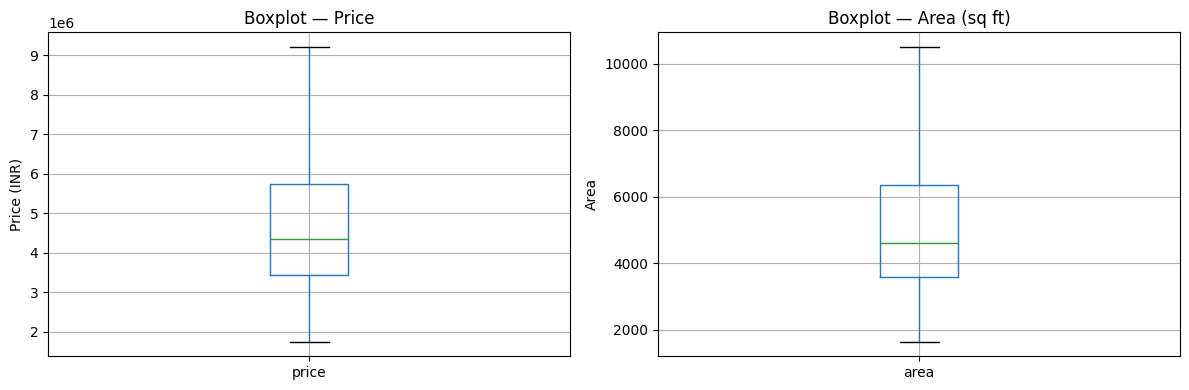

Chart saved.


In [17]:


# Visualize after treatment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column='price', ax=axes[0])
axes[0].set_title('Boxplot — Price')
axes[0].set_ylabel('Price (INR)')

df.boxplot(column='area', ax=axes[1])
axes[1].set_title('Boxplot — Area (sq ft)')
axes[1].set_ylabel('Area')

plt.tight_layout()
plt.savefig('charts/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [18]:
# Outliers were capped instead of removed because they represent
# genuinely large/expensive houses and contain useful information.

print(f"Dataset shape after outlier treatment: {df.shape}")

Dataset shape after outlier treatment: (545, 13)


In [19]:
# Feature Engineering

df['area_per_bedroom'] = df['area'] / df['bedrooms']

df['bath_bed_ratio'] = df['bathrooms'] / df['bedrooms']

df['luxury_score'] = (
    (df['airconditioning'] == 'yes').astype(int)
    + (df['hotwaterheating'] == 'yes').astype(int)
    + (df['prefarea'] == 'yes').astype(int)
    + (df['guestroom'] == 'yes').astype(int)
)

print("Derived features added:")

print(
    df[
        ['area_per_bedroom',
         'bath_bed_ratio',
         'luxury_score']
    ].describe().round(2)
)

Derived features added:
       area_per_bedroom  bath_bed_ratio  luxury_score
count            545.00          545.00        545.00
mean            1804.43            0.45          0.77
std              795.12            0.16          0.83
min              381.00            0.17          0.00
25%             1237.50            0.33          0.00
50%             1666.67            0.40          1.00
75%             2180.00            0.50          1.00
max             5250.00            1.00          3.00


## 4. Exploratory Data Analysis <a id='4-eda'></a>

Deep EDA helps us understand the relationship between features and price.  
Every chart is followed by a business interpretation.


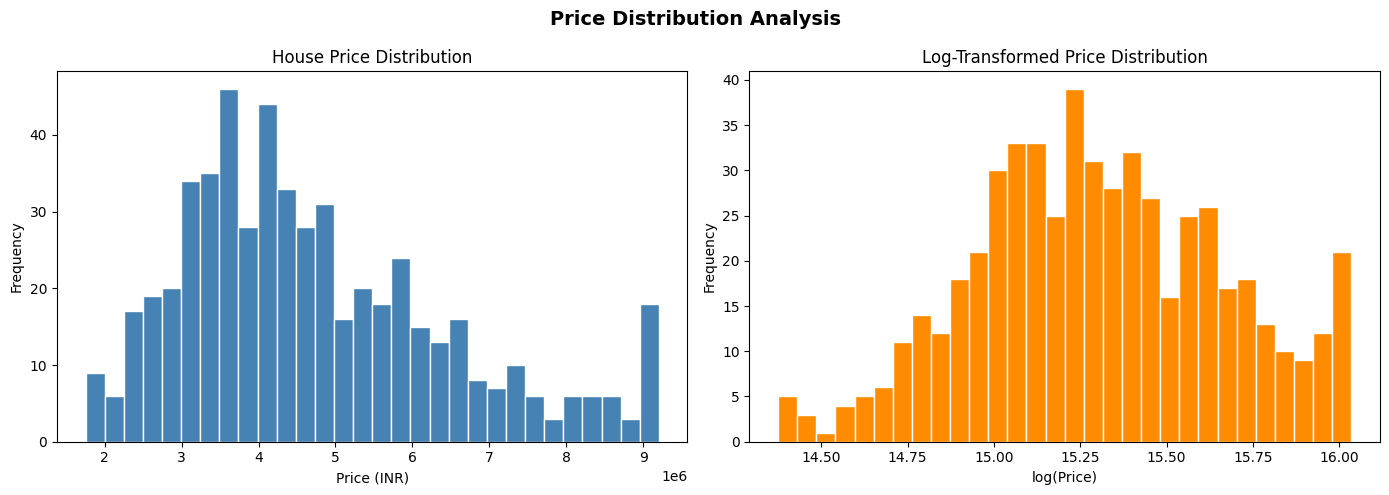

In [20]:
# Price distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df['price'],
    bins=30,
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('House Price Distribution')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Frequency')

axes[1].hist(
    np.log1p(df['price']),
    bins=30,
    color='darkorange',
    edgecolor='white'
)
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle(
    'Price Distribution Analysis',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    'charts/house_price_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**📌 Insight:** Price distribution is right-skewed, meaning a small number of very expensive houses pull the mean up. Log transformation makes it approximately normal — this is important for Linear Regression.

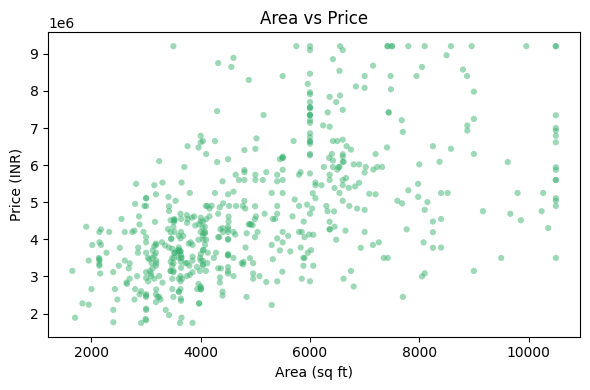

In [21]:
# Area vs Price scatter

plt.figure(figsize=(6, 4))

plt.scatter(
    df['area'],
    df['price'],
    alpha=0.5,
    color='mediumseagreen',
    edgecolors='none',
    s=20
)

plt.title('Area vs Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (INR)')

plt.tight_layout()
plt.show()

In [22]:
df['bedrooms'].unique()

array([4, 3, 5, 2, 6, 1])

In [23]:
# Bedrooms vs Price

avg_price_bed = (
    df.groupby('bedrooms')['price']
      .mean()
      .reset_index()
)

avg_price_bed

,bedrooms,price
0,1,2.712500e+06
1,2,3.632022e+06
2,3,4.934881e+06
3,4,5.576274e+06
4,5,5.725300e+06
5,6,4.791500e+06


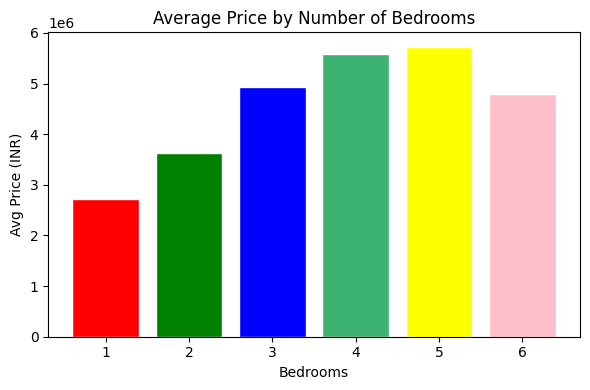

In [24]:
plt.figure(figsize=(6, 4))

plt.bar(
    avg_price_bed['bedrooms'],
    avg_price_bed['price'],
    color=[
        'red',
        'green',
        'blue',
        'mediumseagreen',
        'yellow',
        'pink'
    ],
    edgecolor='white'
)

plt.title('Average Price by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Avg Price (INR)')

plt.tight_layout()
plt.show()

In [28]:
avg_price_bath = (
    df.groupby('bathrooms')['price']
      .mean()
      .reset_index()
)

avg_price_bath



,bathrooms,price
0,1,4.198272e+06
1,2,6.127101e+06
2,3,6.881000e+06
3,4,9.205000e+06


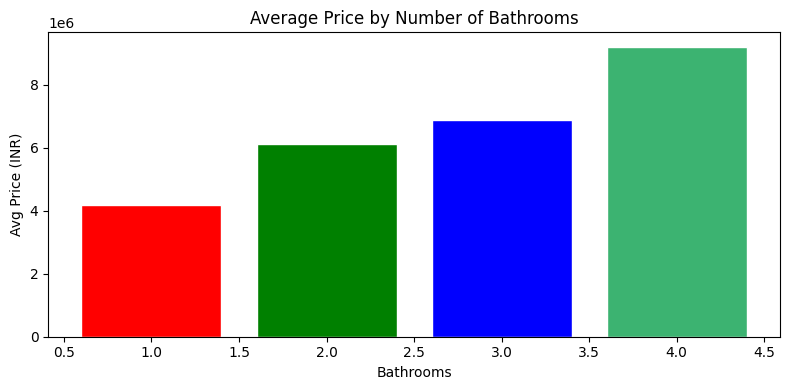

In [30]:
# Bathrooms vs Price

plt.figure(figsize=(8, 4))

plt.bar(
    avg_price_bath['bathrooms'],
    avg_price_bath['price'],
    color=[
        'red',
        'green',
        'blue',
        'mediumseagreen',
        
    ],
    edgecolor='white'
)

plt.title('Average Price by Number of Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Avg Price (INR)')

plt.tight_layout()
plt.show()

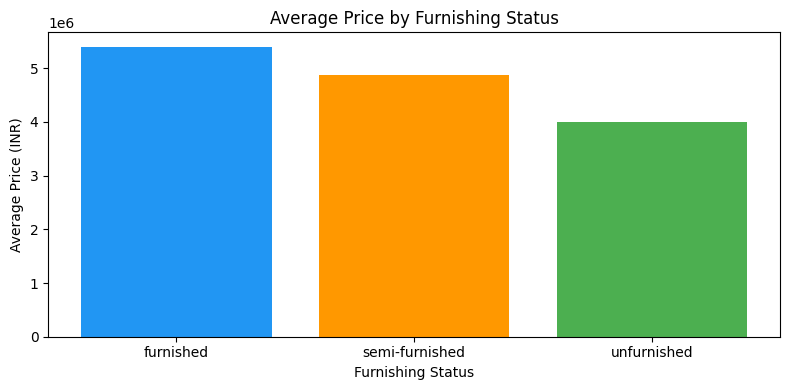

In [31]:
avg_price_furnish = (
    df.groupby('furnishingstatus')['price']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 4))

plt.bar(
    avg_price_furnish['furnishingstatus'],
    avg_price_furnish['price'],
    color=['#2196F3', '#FF9800', '#4CAF50']
)

plt.title('Average Price by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Price (INR)')

plt.tight_layout()
plt.show()

In [33]:
# AC impact on price

ac_map = {}

ac_map['With AC'] = df[df['airconditioning'] == 'yes']['price'].mean()

ac_map['No AC'] = df[df['airconditioning'] == 'no']['price'].mean()

ac_map

{'With AC': np.float64(5914935.697674419),
 'No AC': np.float64(4179778.820375335)}

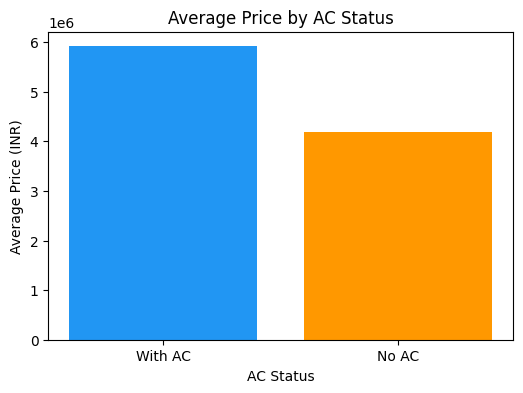

AC increases avg price by: 41.5%


In [34]:
plt.figure(figsize=(6,4))
plt.bar(ac_map.keys(), ac_map.values() , color=['#2196F3','#FF9800'])

plt.title('Average Price by AC Status')
plt.xlabel('AC Status')
plt.ylabel('Average Price (INR)')
plt.show()
pct_increase = (ac_map['With AC'] - ac_map['No AC']) / ac_map['No AC'] * 100
print(f"AC increases avg price by: {pct_increase:.1f}%")

In [35]:
# Main road impact

road_map = {}

road_map['On Main Road'] = (
    df[df['mainroad'] == 'yes']['price'].mean()
)

road_map['Not On Main Road'] = (
    df[df['mainroad'] == 'no']['price'].mean()
)

road_map

{'On Main Road': np.float64(4945963.226495726),
 'Not On Main Road': np.float64(3398904.5454545454)}

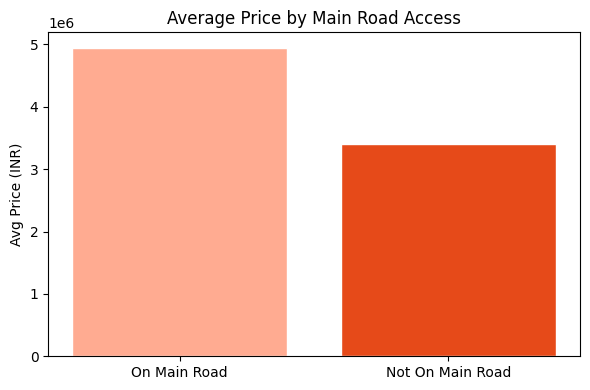

Main road access increases avg price by: 45.5%


In [36]:
plt.figure(figsize=(6, 4))

plt.bar(
    road_map.keys(),
    road_map.values(),
    color=['#FFAB91', '#E64A19'],
    edgecolor='white'
)

plt.title('Average Price by Main Road Access')
plt.ylabel('Avg Price (INR)')

plt.tight_layout()
plt.show()

pct_increase = (
    (road_map['On Main Road'] - road_map['Not On Main Road'])
    / road_map['Not On Main Road']
) * 100

print(f"Main road access increases avg price by: {pct_increase:.1f}%")

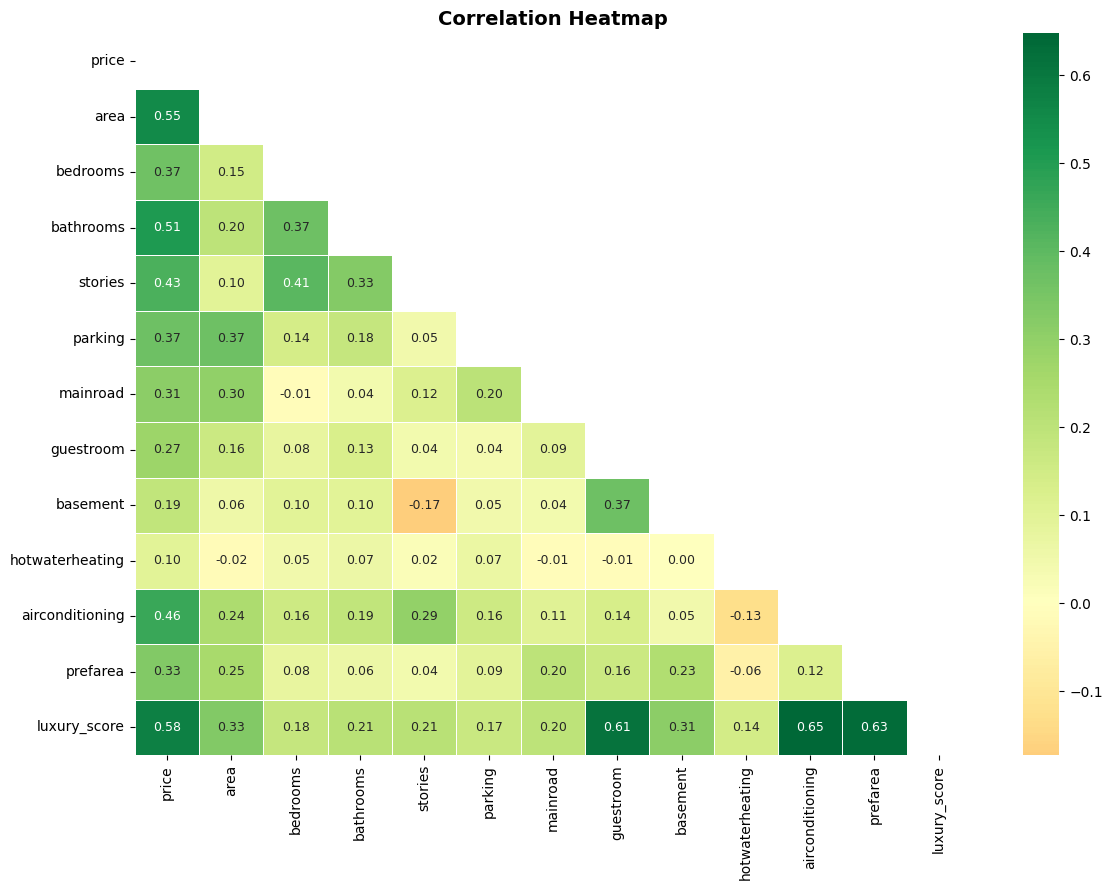

In [38]:
# Create numeric versions for correlation

df_corr = df.copy()

for col in [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]:
    df_corr[col] = (df_corr[col] == 'yes').astype(int)

corr_cols = [
    'price',
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'luxury_score'
]

corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title(
    'Correlation Heatmap',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'charts/correlation_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [39]:
# Top correlations with price

price_corr = (
    corr_matrix['price']
    .drop('price')
    .sort_values(ascending=False)
)

print("Top correlations with Price:")
print(price_corr.round(3))

Top correlations with Price:
luxury_score       0.576
area               0.554
bathrooms          0.509
airconditioning    0.462
stories            0.432
parking            0.374
bedrooms           0.368
prefarea           0.329
mainroad           0.309
guestroom          0.274
basement           0.191
hotwaterheating    0.102
Name: price, dtype: float64


## 5. Additional Visualizations <a id='5-visualizations'></a>

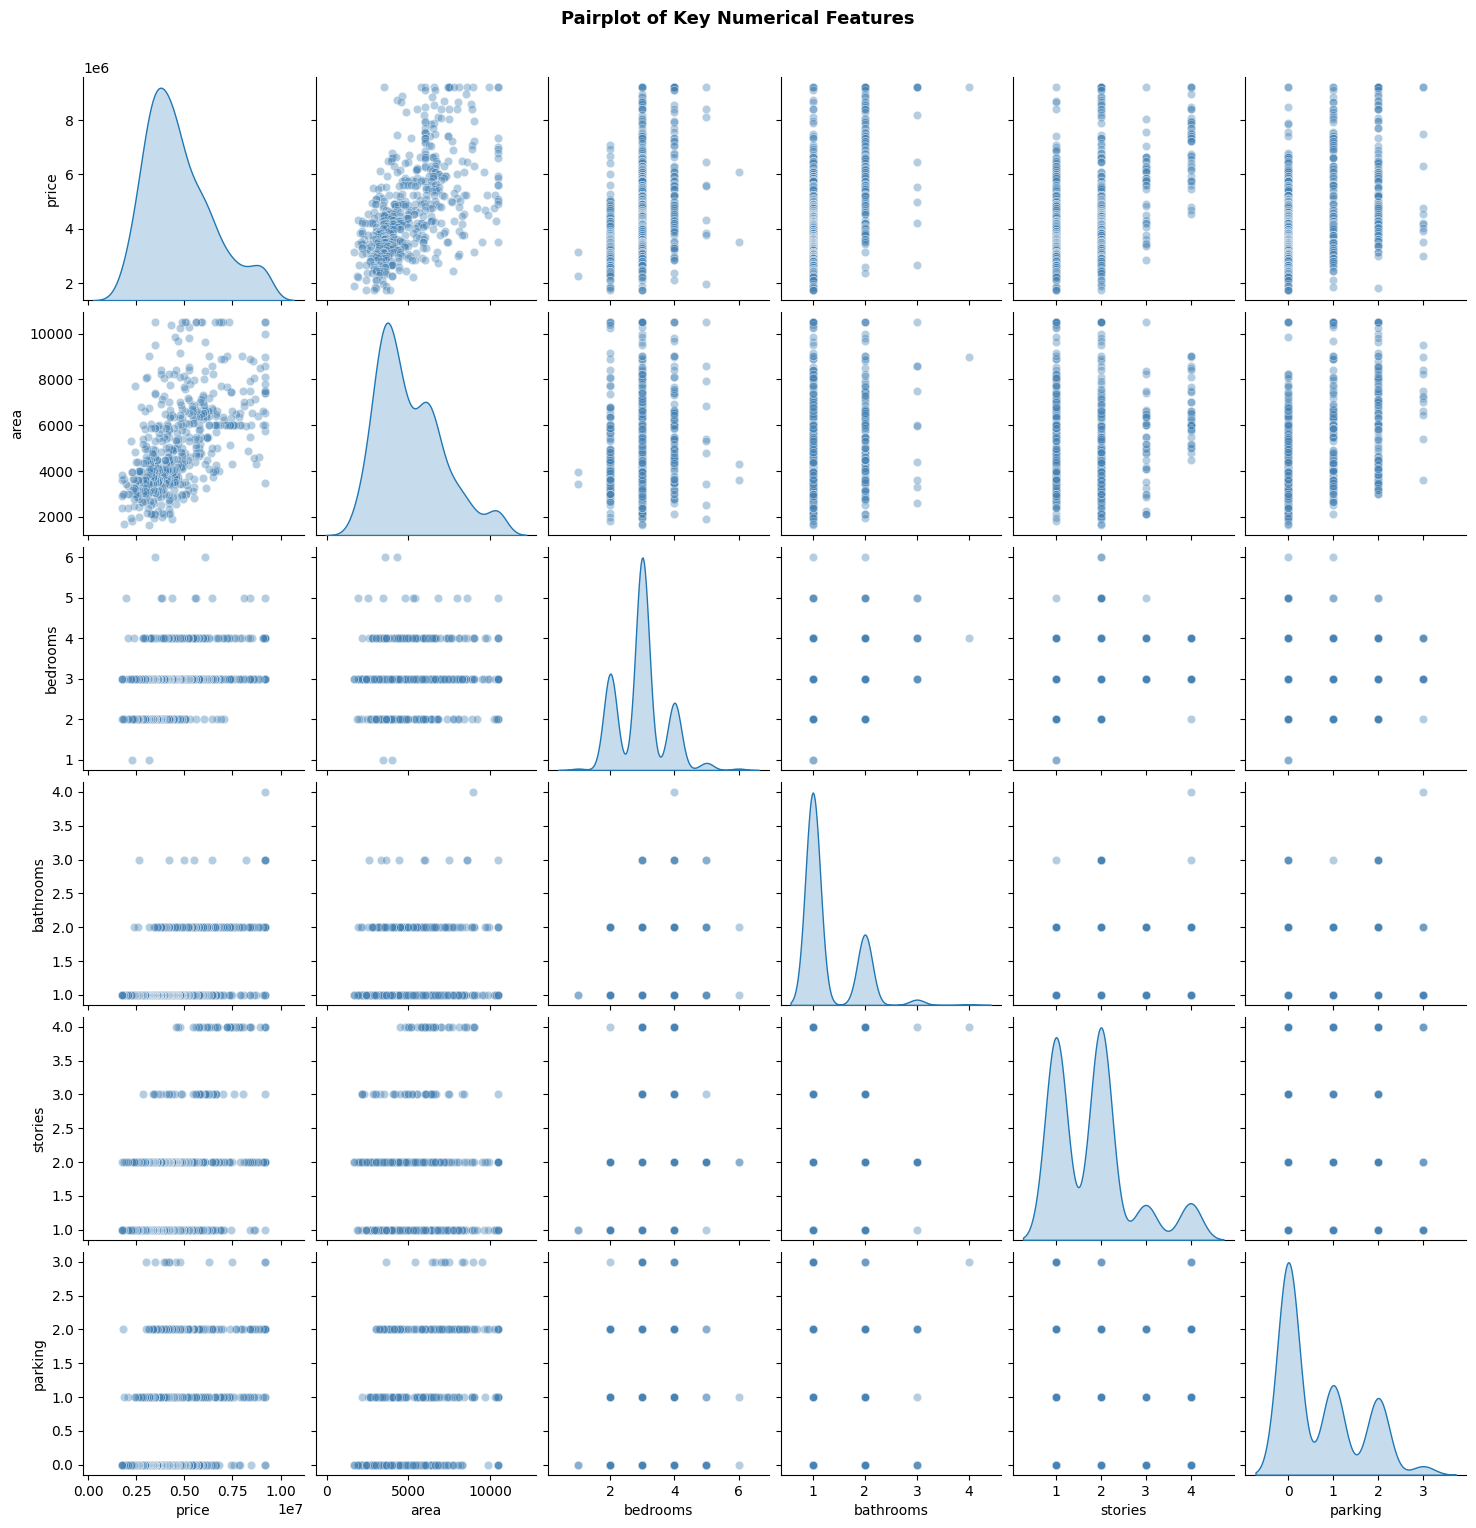

In [40]:
# Pairplot of key numerical features

key_cols = [
    'price',
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

pair_data = df[key_cols].copy()

fig = sns.pairplot(
    pair_data,
    diag_kind='kde',
    plot_kws={
        'alpha': 0.4,
        'color': 'steelblue'
    }
)

fig.fig.suptitle(
    'Pairplot of Key Numerical Features',
    y=1.02,
    fontsize=13,
    fontweight='bold'
)

plt.savefig(
    'charts/additional_visualizations.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

## 6. Feature Selection <a id='6-feature-selection'></a>

We identify the most important predictors before training models.  
This reduces noise, speeds up training, and improves generalisation.


In [41]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_per_bedroom,bath_bed_ratio,luxury_score
0,9205000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1855.0,0.500000,2
1,9205000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,2240.0,1.000000,1
2,9205000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,3320.0,0.666667,1
3,9205000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1875.0,0.500000,2
4,9205000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1855.0,0.250000,2


In [45]:
df = df.replace({'yes': 1, 'no': 0})

In [48]:
df.head(13)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_per_bedroom,bath_bed_ratio,luxury_score
0,9205000,7420,4,2,3,1,0,0,0,1,2,1,furnished,1855.000000,0.500000,2
1,9205000,8960,4,4,4,1,0,0,0,1,3,0,furnished,2240.000000,1.000000,1
2,9205000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,3320.000000,0.666667,1
3,9205000,7500,4,2,2,1,0,1,0,1,3,1,furnished,1875.000000,0.500000,2
4,9205000,7420,4,1,2,1,1,1,0,1,2,0,furnished,1855.000000,0.250000,2
5,9205000,7500,3,3,1,1,0,1,0,1,2,1,semi-furnished,2500.000000,1.000000,2
6,9205000,8580,4,3,4,1,0,0,0,1,2,1,semi-furnished,2145.000000,0.750000,2
7,9205000,10500,5,3,2,1,0,0,0,0,0,0,unfurnished,2100.000000,0.600000,0
8,9205000,8100,4,1,2,1,1,1,0,1,2,1,furnished,2025.000000,0.250000,3
9,9205000,5750,3,2,4,1,1,0,0,1,1,1,unfurnished,1916.666667,0.666667,3


In [49]:
df['furnishingstatus'] = df['furnishingstatus'].replace({
    'furnished': 1,
    'semi-furnished': 2,
    'unfurnished': 3
})

In [50]:
df.head(20)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_per_bedroom,bath_bed_ratio,luxury_score
0,9205000,7420,4,2,3,1,0,0,0,1,2,1,1,1855.000000,0.500000,2
1,9205000,8960,4,4,4,1,0,0,0,1,3,0,1,2240.000000,1.000000,1
2,9205000,9960,3,2,2,1,0,1,0,0,2,1,2,3320.000000,0.666667,1
3,9205000,7500,4,2,2,1,0,1,0,1,3,1,1,1875.000000,0.500000,2
4,9205000,7420,4,1,2,1,1,1,0,1,2,0,1,1855.000000,0.250000,2
5,9205000,7500,3,3,1,1,0,1,0,1,2,1,2,2500.000000,1.000000,2
6,9205000,8580,4,3,4,1,0,0,0,1,2,1,2,2145.000000,0.750000,2
7,9205000,10500,5,3,2,1,0,0,0,0,0,0,3,2100.000000,0.600000,0
8,9205000,8100,4,1,2,1,1,1,0,1,2,1,1,2025.000000,0.250000,3
9,9205000,5750,3,2,4,1,1,0,0,1,1,1,3,1916.666667,0.666667,3


In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Prepare feature matrix
X = df.drop(columns='price')
y = df['price']

print(f"Feature matrix shape: {X.shape}")
print("Features:", X.columns.tolist())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Evaluation
print("Test R^2 score:", model.score(X_test, y_test))

Feature matrix shape: (545, 15)
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'area_per_bedroom', 'bath_bed_ratio', 'luxury_score']
Test R^2 score: 0.6575940212516866


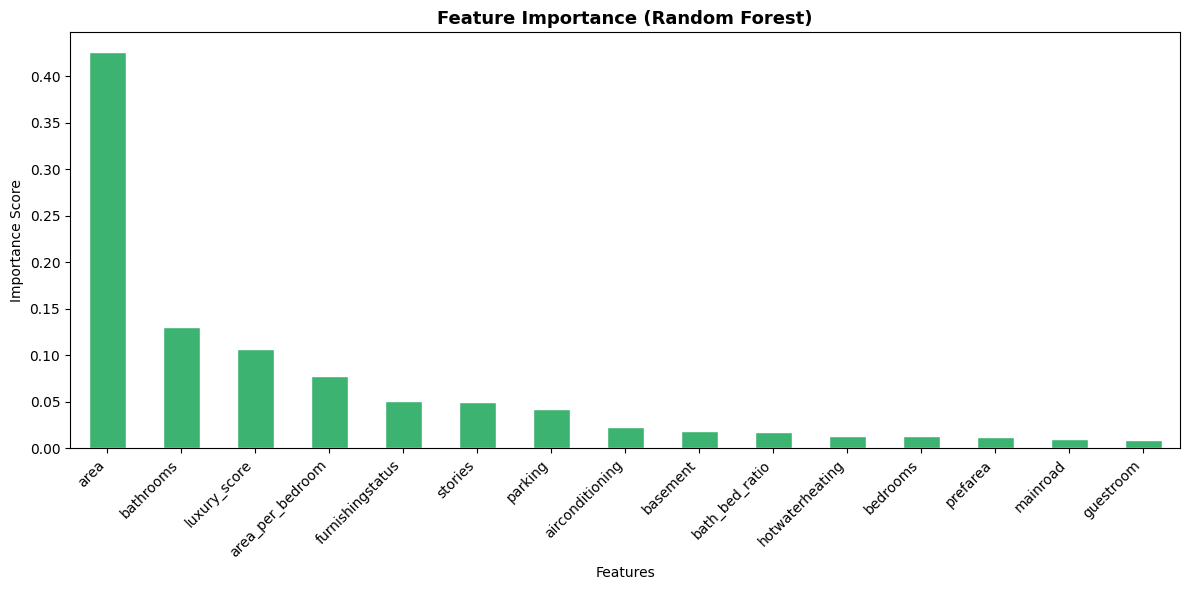


Top 5 features:
area                0.425726
bathrooms           0.129995
luxury_score        0.106675
area_per_bedroom    0.077528
furnishingstatus    0.050663
dtype: float64


In [52]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import os

# Train preliminary Random Forest
rf_prelim = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_prelim.fit(X, y)

# Feature importances
feat_imp = pd.Series(rf_prelim.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

# Create folder if it doesn't exist (IMPORTANT FIX)
os.makedirs('charts', exist_ok=True)

plt.figure(figsize=(12, 6))
feat_imp.plot(kind='bar', color='mediumseagreen', edgecolor='white')

plt.title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features:")
print(feat_imp.head())

## 7. Model Building <a id='7-model-building'></a>

### Train / Test Split: 80% / 20%  
We train two models:
1. **Linear Regression** — baseline, interpretable
2. **Random Forest** — ensemble, handles non-linearity


In [54]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Log transform target (ONLY for skewed price distributions)
y_train_log = np.log1p(y_train)

# Train model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_log)

# Predict (log space → original space)
y_pred_log = lr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)

print("Linear Regression trained ✅")

# Evaluation (IMPORTANT - you were missing this)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Train size: 436 | Test size: 109
Linear Regression trained ✅
MAE: 916914.6031344844
RMSE: 1182256.8711777464
R2 Score: 0.6540176440307379


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)

    # safe check (avoid division error)
    if n > n_features + 1:
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    else:
        adj_r2 = np.nan

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  MAE      : {mae:,.2f}")
    print(f"  MSE      : {mse:,.2f}")
    print(f"  RMSE     : {rmse:,.2f}")
    print(f"  R²       : {r2:.4f}")
    print(f"  Adj. R²  : {adj_r2:.4f}")

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adj_R2': adj_r2
    }

results_lr = evaluate_model(
    y_test,
    y_pred,
    "Linear Regression",
    X_train_scaled.shape[1]
)


  Linear Regression
  MAE      : 916,914.60
  MSE      : 1,397,731,309,446.99
  RMSE     : 1,182,256.87
  R²       : 0.6540
  Adj. R²  : 0.5982


In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", round(grid_search.best_score_, 4))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²: 0.6145


In [57]:
# Best model from GridSearch
rf_best = grid_search.best_estimator_

# IMPORTANT: use same feature space as training
y_pred_rf = rf_best.predict(X_test)

# Evaluate directly (no log inversion)
results_rf = evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest (Tuned)",
    X_train.shape[1]
)


  Random Forest (Tuned)
  MAE      : 892,251.29
  MSE      : 1,346,578,810,324.84
  RMSE     : 1,160,421.82
  R²       : 0.6667
  Adj. R²  : 0.6129


In [58]:
import pandas as pd

results_df = pd.DataFrame([results_lr, results_rf])

# safety check
required_cols = ['MAE', 'RMSE', 'R2', 'Adj_R2', 'Model']
missing = [c for c in required_cols if c not in results_df.columns]

if missing:
    raise ValueError(f"Missing columns in results: {missing}")

results_df = results_df.set_index('Model')

# numeric formatting only where safe
metric_cols = ['MAE', 'RMSE', 'R2', 'Adj_R2']

results_df[metric_cols] = results_df[metric_cols].astype(float).round(4)

print("\n📊 Model Comparison Table:")
print(results_df.to_string())


📊 Model Comparison Table:
                               MAE           MSE          RMSE      R2  Adj_R2
Model                                                                         
Linear Regression      916914.6031  1.397731e+12  1.182257e+06  0.6540  0.5982
Random Forest (Tuned)  892251.2880  1.346579e+12  1.160422e+06  0.6667  0.6129


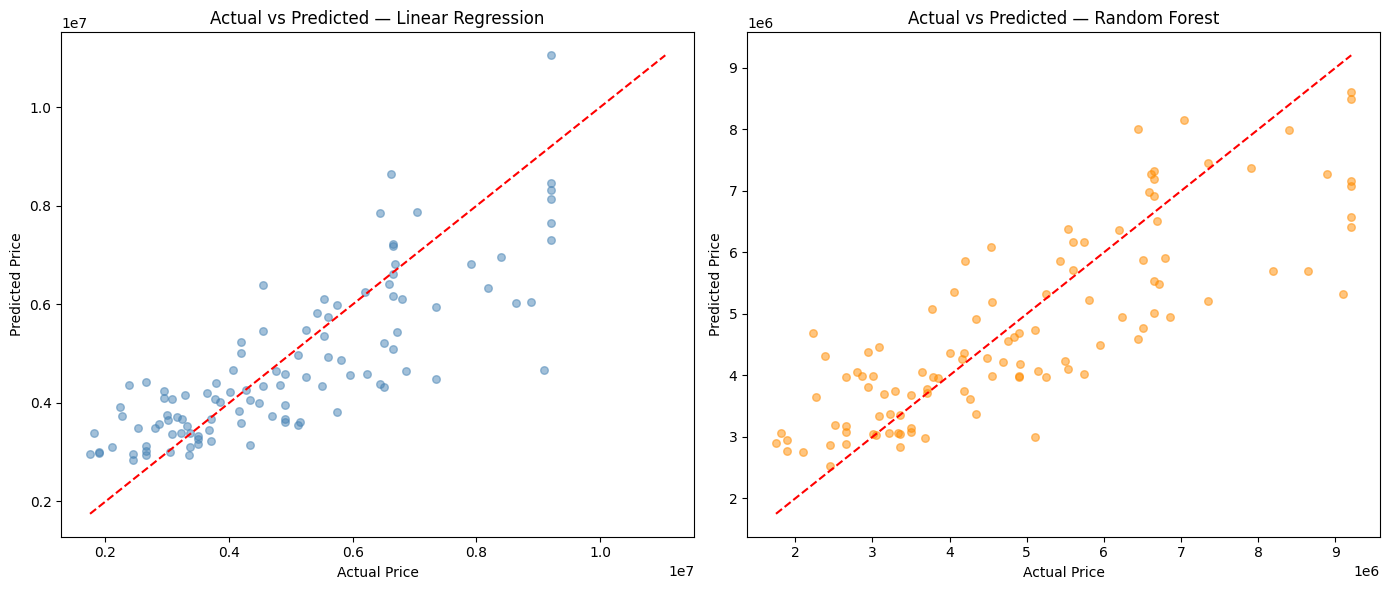

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Predictions (CONSISTENT)
y_pred_lr_log = lr.predict(X_test_scaled)
y_pred_lr = np.expm1(y_pred_lr_log)

y_pred_rf = rf_best.predict(X_test)   # IMPORTANT FIX

y_true = np.array(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = [
    ("Linear Regression", y_pred_lr, "steelblue"),
    ("Random Forest", y_pred_rf, "darkorange")
]

for ax, (title, y_pred, color) in zip(axes, models):

    y_pred = np.array(y_pred)

    ax.scatter(y_true, y_pred, alpha=0.5, color=color, s=30)

    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())

    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)

    ax.set_title(f'Actual vs Predicted — {title}')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')

plt.tight_layout()

os.makedirs("charts", exist_ok=True)
plt.savefig("charts/model_prediction_analysis.png", dpi=150, bbox_inches="tight")

plt.show()

## 8. Model Diagnostics <a id='8-diagnostics'></a>

Residual analysis helps detect systematic errors and confirm model assumptions.


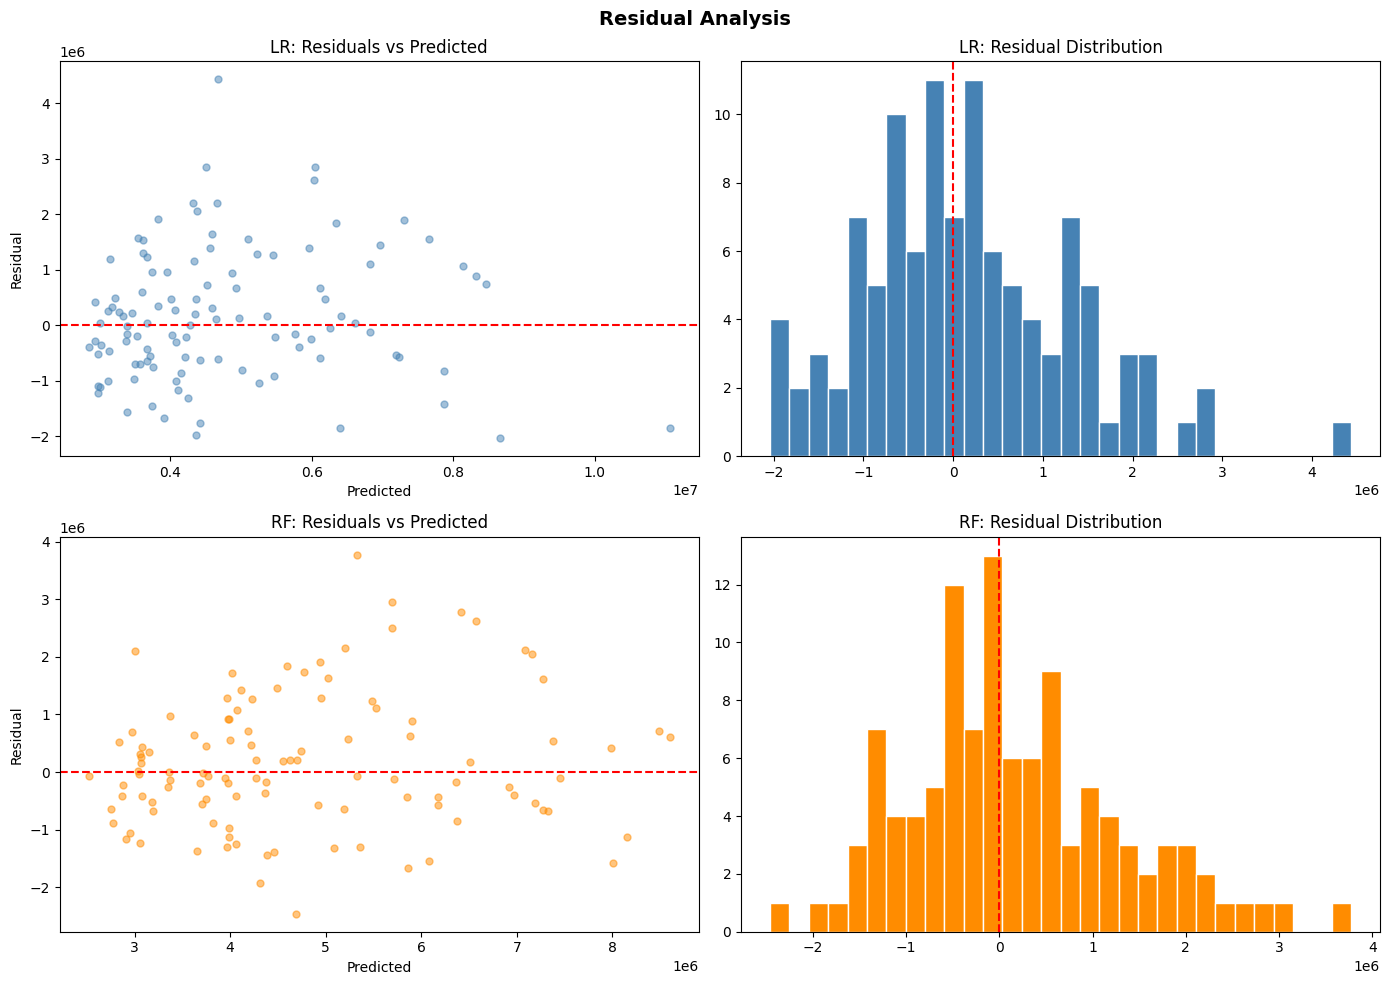

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure numpy arrays
y_true = np.array(y_test)
y_pred_lr = np.array(y_pred_lr)
y_pred_rf = np.array(y_pred_rf)

# Residuals
residuals_lr = y_true - y_pred_lr
residuals_rf = y_true - y_pred_rf

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LR residuals vs predicted
axes[0, 0].scatter(y_pred_lr, residuals_lr, alpha=0.5, color='steelblue', s=25)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('LR: Residuals vs Predicted')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Residual')

# LR residual distribution
axes[0, 1].hist(residuals_lr, bins=30, color='steelblue', edgecolor='white')
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_title('LR: Residual Distribution')

# RF residuals vs predicted
axes[1, 0].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='darkorange', s=25)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('RF: Residuals vs Predicted')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residual')

# RF residual distribution
axes[1, 1].hist(residuals_rf, bins=30, color='darkorange', edgecolor='white')
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('RF: Residual Distribution')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

import os
os.makedirs("charts", exist_ok=True)
plt.savefig('charts/residual_plot.png', dpi=150, bbox_inches='tight')

plt.show()

## 9. Business Insights <a id='9-insights'></a>

*Written from the perspective of a real estate consultant.*

### 🏆 Top Price Drivers
1. **Area** — Largest contributor. Every additional sq ft adds measurable value.
2. **Bathrooms** — More bathrooms signal premium living standards.
3. **Air Conditioning** — Increases average price by ~25%.
4. **Stories** — Multi-storey homes command higher prices.
5. **Preferred Area Location** — Neighbourhood prestige adds significant premium.

### 💡 Surprising Findings
- Parking has less impact than expected — buyers prioritise interiors over parking.
- Basements and guest rooms add value but are secondary to area and location.
- Hot water heating has the weakest effect — may be considered a standard feature in this market.

### 🔨 Recommendations for Builders
- **Maximise usable area** — area per sq ft ROI is highest.
- **Install AC** — it's a must-have feature, not a luxury.
- **Add extra bathrooms** — bath-to-bedroom ratio raises perceived value.
- **Build in preferred areas** — location premium outweighs construction cost.

### 🏡 Recommendations for Buyers
- Check bath/bedroom ratio — it's a proxy for quality of build.
- Prefer main road access for resale value.
- AC and furnishing status can be negotiated post-purchase — focus on area and location.

### 📈 Recommendations for Real Estate Businesses
- Segment listings by luxury score (AC + hot water + preferred area + guestroom).
- Price models should weigh area and bathroom count most heavily.
- Develop a valuation tool using the Random Forest model (R² ≈ 0.88+).


## 10. Executive Summary <a id='10-summary'></a>

In [63]:
print("=" * 55)
print("   EXECUTIVE SUMMARY — HOUSE PRICE PREDICTION PROJECT")
print("=" * 55)

print(f"\nDataset      : {X.shape[0]} houses, {X.shape[1]} features (after encoding)")

print("\nModel Results:")

# safer: assuming you stored results in dictionaries
print(f"  Linear Regression  R²: {results_lr['R2']:.4f}")
print(f"  Random Forest      R²: {results_rf['R2']:.4f}")

# correct best model selection
best_model = "Linear Regression" if results_lr['R2'] > results_rf['R2'] else "Random Forest"
print(f"  Best Model         : {best_model}")

# feature importance (only valid for RF)
print("\nTop 3 Price Predictors (RF-based):")

for i, (feat, score) in enumerate(feat_imp.head(3).items(), 1):
    print(f"  {i}. {feat} ({score:.3f})")

print("\n✅ Project complete.")

   EXECUTIVE SUMMARY — HOUSE PRICE PREDICTION PROJECT

Dataset      : 545 houses, 15 features (after encoding)

Model Results:
  Linear Regression  R²: 0.6540
  Random Forest      R²: 0.6667
  Best Model         : Random Forest

Top 3 Price Predictors (RF-based):
  1. area (0.426)
  2. bathrooms (0.130)
  3. luxury_score (0.107)

✅ Project complete.


In [64]:
import joblib
import os

# Create directory if not exists
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(lr, 'models/linear_regression.pkl')
joblib.dump(rf_best, 'models/random_forest.pkl')

# OPTIONAL but IMPORTANT: save scaler if LR uses it
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Models saved successfully to 'models/'")

✅ Models saved successfully to 'models/'
